Time for some optimization! The algorithms are optimized on 21 days of data. After that the algorithms are tested again.

In [28]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

df_full = pd.read_csv("summary_119.csv")
df_full["Measurement date"] = pd.to_datetime(df_full["Measurement date"])

#we ditch the coloumns of date, code, position and adress for now.

df = df_full.drop(columns=['Measurement date','Address','Station code', 'Latitude', 'Longitude'])

df.head()

,SO2,NO2,O3,CO,PM10,PM2.5,PM10_raw
0,0.005,0.035,0.004,1.5,70.0,46.0,215.000053
1,0.004,0.034,0.004,1.5,68.0,54.0,193.715523
2,0.005,0.035,0.004,1.6,71.0,54.0,193.693620
3,0.004,0.033,0.004,1.7,65.0,46.0,142.891511
4,0.004,0.028,0.004,1.6,60.0,42.0,123.267815


In [29]:
def make_fixed_split(df, days):

    train_points = days*24
    half = len(df) // 2

    train_val_df = df.iloc[half-train_points:half].copy()
    test_df = df.iloc[half:].copy()

    x_train = train_val_df.drop("PM10", axis=1)
    y_train = train_val_df["PM10"]

    x_test = test_df.drop("PM10", axis=1)
    y_test = test_df["PM10"]

    return x_train, y_train, x_test, y_test

In [30]:
x_train, y_train, x_test, y_test = make_fixed_split(df,21)


from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, x_test["PM10_raw"])

print('Baseline Root Mean Squared Error:', rmse)

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

Baseline Root Mean Squared Error: 166.8001957147937
(504, 6) (504,) (12939, 6) (12939,)


https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/
https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/
https://www.kaggle.com/discussions/general/555096
https://www.geeksforgeeks.org/machine-learning/comparing-randomized-search-and-grid-search-for-hyperparameter-estimation-in-scikit-learn/


RandomizedSearch will be used for the optimization. We start off with Random Forest

In [31]:
iterations = 100 # higher = better but longer time

param_distributions = {
    'n_estimators': randint(10,2000),
    'max_depth': [5, 10, 15, 20, 30, None],
    "max_features": randint(1, 9),
    "min_samples_leaf": randint(1, 9),
    'min_samples_split': randint(2, 21),
    'bootstrap': [True, False]
}


model = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
  model,
  param_distributions, 
  cv=TimeSeriesSplit(n_splits=5), 
  n_iter=iterations, 
  random_state=42)
random_search.fit(x_train, y_train)

RF_Bestparams = random_search.best_params_

print(f"Best hyperparameters found by RandomizedSearchCV: {random_search.best_params_}")

Best hyperparameters found by RandomizedSearchCV: {'bootstrap': False, 'max_depth': 30, 'max_features': 4, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 521}


In [32]:
param_distributions = {
    'max_depth': [5, 10, 15, 20, 30, None],
    "max_features": randint(1, 9),
    "min_samples_leaf": randint(1, 9),
    'min_samples_split': randint(2, 21),
}


model = DecisionTreeRegressor(random_state=42)

random_search = RandomizedSearchCV(
  model,
  param_distributions, 
  cv=TimeSeriesSplit(n_splits=5), 
  n_iter=iterations, 
  random_state=42)
random_search.fit(x_train, y_train)

DT_Bestparams = random_search.best_params_

print(f"Best hyperparameters found by RandomizedSearchCV: {random_search.best_params_}")

Best hyperparameters found by RandomizedSearchCV: {'max_depth': 20, 'max_features': 7, 'min_samples_leaf': 1, 'min_samples_split': 9}


In [33]:
param_distributions = {
    'n_estimators': randint(10,2000),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5, 6],
    "max_features": randint(1, 9),
    "min_samples_leaf": randint(1, 9),
    'min_samples_split': randint(2, 21),
    'subsample': [0.6,0.8,1.0],
}


model = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
  model,
  param_distributions, 
  cv=TimeSeriesSplit(n_splits=5), 
  n_iter=iterations, 
  random_state=42)
random_search.fit(x_train, y_train)

GB_Bestparams = random_search.best_params_

print(f"Best hyperparameters found by RandomizedSearchCV: {random_search.best_params_}")

Best hyperparameters found by RandomizedSearchCV: {'learning_rate': 0.1, 'max_depth': 2, 'max_features': 6, 'min_samples_leaf': 1, 'min_samples_split': 18, 'n_estimators': 71, 'subsample': 0.6}


In [34]:
param_distributions = {
    "hidden_layer_sizes": [(32,), (64,), (32,16), (64,32), (64,64),(64,32,16)],
    "activation": ["relu", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "learning_rate_init": [1e-4, 1e-3, 1e-2],
    "learning_rate": ["constant", "adaptive"],
    "batch_size": [16, 32, 64, 128],
    "max_iter": [500, 1000, 2000],
}


model = MLPRegressor(random_state=42)

random_search = RandomizedSearchCV(
  model,
  param_distributions, 
  cv=TimeSeriesSplit(n_splits=5), 
  n_iter=iterations, 
  random_state=42)
random_search.fit(x_train, y_train)

MLP_Bestparams = random_search.best_params_

print(f"Best hyperparameters found by RandomizedSearchCV: {random_search.best_params_}")

C:\Users\nisse\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nisse\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\nisse\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
C:\Users\nisse\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\nisse\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:227: RuntimeWarning: invalid 

Best hyperparameters found by RandomizedSearchCV: {'solver': 'adam', 'max_iter': 500, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (64, 32, 16), 'batch_size': 32, 'alpha': 0.01, 'activation': 'relu'}


In [35]:
#days_list = [7, 14, 21, 42]
days_list = list(range(2,15))

results = []

for days in days_list:
    x_train, y_train, x_test, y_test = make_fixed_split(df, days)

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(
            **DT_Bestparams,
            random_state=42),
        "Random Forest": RandomForestRegressor(
            **RF_Bestparams,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            **GB_Bestparams,
            random_state=42
        ),
        "MLP Regressor":MLPRegressor(
            **MLP_Bestparams,
            random_state=42
        )
    }

    for model_name, model in models.items():
        model.fit(x_train, y_train)
        gb_y_pred = model.predict(x_test)

        rmse = np.sqrt(mean_squared_error(y_test, gb_y_pred))
        mae = mean_absolute_error(y_test, gb_y_pred)
        r2 = r2_score(y_test, gb_y_pred)

        results.append({
            "Days": days,
            "Train points": days * 24,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Days", "RMSE"])
results_df

,Days,Train points,Model,RMSE,MAE,R2
3,2,48,Gradient Boosting,75.774895,18.007316,0.114608
2,2,48,Random Forest,76.670169,19.513479,0.093562
1,2,48,Decision Tree,76.784740,19.701259,0.090851
4,2,48,MLP Regressor,84.904463,18.752884,-0.111594
0,2,48,Linear Regression,105.468492,20.944251,-0.715262
...,...,...,...,...,...,...
63,14,336,Gradient Boosting,29.639134,11.073593,0.864538
62,14,336,Random Forest,31.076891,11.856518,0.851078
61,14,336,Decision Tree,31.146459,13.020397,0.850410
64,14,336,MLP Regressor,33.105316,14.021588,0.831002


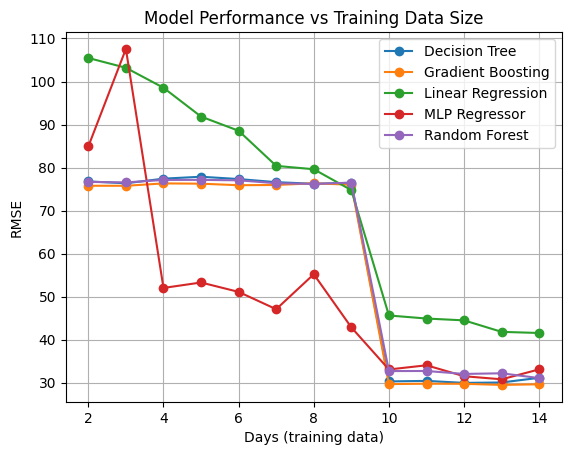

In [36]:
pivot_df = results_df.pivot(index="Days", columns="Model", values="RMSE")

plt.figure()

for model in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[model], marker='o', label=model)

plt.xlabel("Days (training data)")
plt.ylabel("RMSE")
plt.title("Model Performance vs Training Data Size")
plt.legend()
plt.grid()

plt.show()

All of the regressors are optimized on 21 days of data since this gave the best results. This was however little to no improvement. If they were optimized on 7 days they perform bad since they probably overfit the train set which does not represent the rest of the data very well. If the algorithms are optimized on a year of data the RMSE shoots up again. My theory is that it is due to the difference in the quantities of optimization data and the training data.

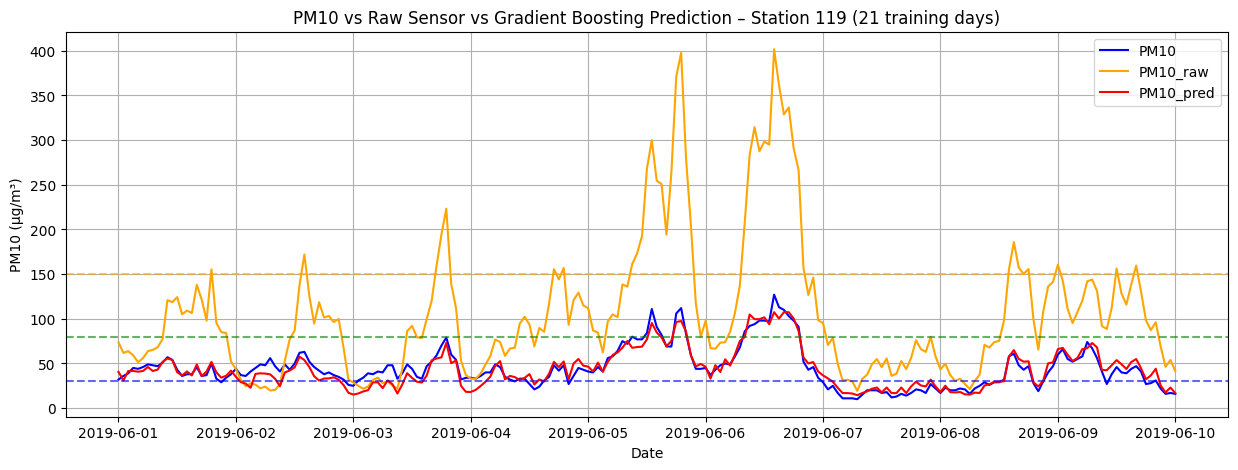

In [37]:
days = 21
x_train, y_train, x_test, y_test = make_fixed_split(df, days)

gb_model = GradientBoostingRegressor(
    **GB_Bestparams,
    random_state=42
)

gb_model.fit(x_train, y_train)
gb_y_pred = gb_model.predict(x_test)

half = len(df_full) // 2
test_plot_df = df_full.iloc[half:].copy()
test_plot_df["PM10_pred"] = gb_y_pred

date_range = ['2019-06-01', '2019-06-10']

df_plot = test_plot_df[
    (test_plot_df['Measurement date'] >= date_range[0]) &
    (test_plot_df['Measurement date'] <= date_range[1])
].copy()

plt.figure(figsize=(15,5))

plt.plot(df_plot['Measurement date'], df_plot['PM10'], label='PM10', color='blue')
plt.plot(df_plot['Measurement date'], df_plot['PM10_raw'], label='PM10_raw', color='orange')
plt.plot(df_plot['Measurement date'], df_plot['PM10_pred'], label='PM10_pred', color='red')

plt.axhline(30, color='blue', linestyle='--', alpha=0.6, )
plt.axhline(80, color='green', linestyle='--', alpha=0.6, )
plt.axhline(150, color='orange', linestyle='--', alpha=0.6, )

plt.title(f'PM10 vs Raw Sensor vs Gradient Boosting Prediction – Station 119 ({days} training days)')
plt.xlabel('Date')
plt.ylabel('PM10 (µg/m³)')
plt.legend()
plt.grid(True)
plt.show()

Here the results from the Gradient Booster are visualized showing major improvement. The simulated sensor har a RMSE of 166.8. This was decreased to a RMSE of just under 30 indicating a decrease of RMSE of 82%. The linear regressor performs a minimum RMSE of 41.56. If instead the RMSE of of the linear regressor is selected as the baseline value it is still a decrease of 28%!

The experiment is a sucess. It is proven that AI has the potential to effectively calibrate sensors. Below is some code showing why I chose not to scale the data for for the MLP-regressor.

In [38]:

days = 21
x_train, y_train, x_test, y_test = make_fixed_split(df, days)

mlp = MLPRegressor(
    hidden_layer_sizes=(32,16),
    max_iter=1000,
    random_state=42
)

mlp.fit(x_train, y_train)
y_pred = mlp.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(rmse)
print(mae)
print(r2)

34.830747106115965
12.777407924054359
0.8129272048419651


https://github.com/marcel-krause/Hands-On-Machine-Learning/blob/main/Chapter%2010%20-%20Introduction%20to%20Artificial%20Neural%20Networks%20with%20Keras/Chapter%2010%20-%20A%20Sequential%20Regression%20MLP%20for%20the%20California%20Housing%20Problem.ipynb

In [39]:
from sklearn.preprocessing import StandardScaler

tf.keras.backend.clear_session()

days = 21
x_train, y_train, x_test, y_test = make_fixed_split(df, days)

scaler = StandardScaler()

split = int(len(x_train) * 0.5)

x_val = x_train[split:]
y_val = y_train[split:]

x_train = x_train[:split]
y_train = y_train[:split]

#x_train = scaler.fit_transform(x_train)
#x_test = scaler.transform(x_test)
#x_val = scaler.transform(x_val)

model = keras.models.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=x_train.shape[1:]),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

early_stopping = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)



model.compile(loss='mean_squared_error', optimizer='adam', 
    metrics=[tf.keras.metrics.RootMeanSquaredError()])


history = model.fit(x_train, y_train, epochs=500, callbacks=[early_stopping],validation_data=(x_val, y_val))

c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 6589.8223 - root_mean_squared_error: 81.1777 - val_loss: 4967.9146 - val_root_mean_squared_error: 70.4834
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4289.8843 - root_mean_squared_error: 65.4972 - val_loss: 3351.5203 - val_root_mean_squared_error: 57.8923
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2835.7029 - root_mean_squared_error: 53.2513 - val_loss: 2306.6951 - val_root_mean_squared_error: 48.0281
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1797.0951 - root_mean_squared_error: 42.3922 - val_loss: 1592.4789 - val_root_mean_squared_error: 39.9059
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1141.5280 - root_mean_squared_error: 33.7865 - val_loss: 1106.0610 - val_root_mean_squared_error: 33.2575
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 722.6889 - root_mean_squared_error: 26.8829 - val_loss: 801.1616 - val_root_mean_squared_error: 28.3048
Epoch 7/500
8/8 ━━

In [40]:
y_pred = model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
RMSE: 38.04210014874775
MAE: 17.678412938773814
R2: 0.7768411963969155


Now we do the exact same code but include the scaler.

In [41]:
from sklearn.preprocessing import StandardScaler

tf.keras.backend.clear_session()

days = 21
x_train, y_train, x_test, y_test = make_fixed_split(df, days)

scaler = StandardScaler()

split = int(len(x_train) * 0.5)

x_val = x_train[split:]
y_val = y_train[split:]

x_train = x_train[:split]
y_train = y_train[:split]

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)

model = keras.models.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=x_train.shape[1:]),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

early_stopping = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)



model.compile(loss='mean_squared_error', optimizer='adam', 
    metrics=[tf.keras.metrics.RootMeanSquaredError()])


history = model.fit(x_train, y_train, epochs=500, callbacks=[early_stopping],validation_data=(x_val, y_val))

Epoch 1/500


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 9741.2402 - root_mean_squared_error: 98.6977 - val_loss: 10777.6758 - val_root_mean_squared_error: 103.8156
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9724.4453 - root_mean_squared_error: 98.6126 - val_loss: 10759.5352 - val_root_mean_squared_error: 103.7282
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9709.3057 - root_mean_squared_error: 98.5358 - val_loss: 10741.2881 - val_root_mean_squared_error: 103.6402
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9693.7861 - root_mean_squared_error: 98.4570 - val_loss: 10721.6748 - val_root_mean_squared_error: 103.5455
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9676.6387 - root_mean_squared_error: 98.3699 - val_loss: 10699.9873 - val_root_mean_squared_error: 103.4407
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9657.6787 - root_mean_squared_error: 98.2735 - val_loss: 10675.9043 - val_root_mean_squared_error: 103.3243
Epoch 7/500
8/8 

In [42]:
y_pred = model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step
RMSE: 85.19399503688265
MAE: 25.88084612345574
R2: -0.11918794555927237


As soon as standardscaler is included in the code, the rmse rises from 38 to 85. My theory is that the maximum values of the train data are so much lower then the maximum of the test data. This results in inconsistent scaling and poor results.